# Ch02 — A2C (Actor–Critic) na CartPole — wersja rozgrzewkowa

Cel: przejść od "DQN = Q(s,a)" do "policy-based": uczymy **politykę** $\pi_\theta(a|s)$ i **wartość** $V_\phi(s)$.

A2C (minimalnie):
- zbieramy rollout (np. cały epizod),
- liczymy return $G_t$,
- advantage: $A_t = G_t - V_\phi(s_t)$,
- uczymy:
  - actor: minimalizujemy $-\log \pi_\theta(a_t|s_t)\,A_t$,
  - critic: minimalizujemy błąd $V_\phi(s_t)$ vs $G_t$ (Huber/MSE),
  - (opcjonalnie) entropy bonus dla eksploracji.


In [2]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import gymnasium as gym


# --- device (jak u Ciebie) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)


# --- reproducibility ---
def seed_everything(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# --- env wrappers (jak w Ch01) ---
def make_env(env_id="CartPole-v1", seed=0, render=False):
    env = gym.make(env_id, render_mode=("human" if render else None))
    env.reset(seed=seed)
    env.action_space.seed(seed)
    return env

def reset_env(env, seed=None):
    obs, _ = env.reset(seed=seed)
    return obs

def step_env(env, action):
    obs2, r, terminated, truncated, _ = env.step(int(action))
    done = bool(terminated or truncated)
    return obs2, float(r), done


# --- evaluation (jak w Ch01): policy_fn(obs)->action(int) ---
def evaluate_policy(env_id, policy_fn, episodes=20, seed=123):
    env = make_env(env_id, seed=seed, render=False)
    rets = []
    for k in range(episodes):
        obs = reset_env(env, seed=seed + k)
        done = False
        ep_ret = 0.0
        while not done:
            a = int(policy_fn(obs))
            obs, r, done = step_env(env, a)
            ep_ret += r
        rets.append(ep_ret)
    env.close()
    return float(np.mean(rets)), float(np.std(rets))


def moving_average(x, w=50):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")


device = cpu


In [3]:
class ActorNet(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, act_dim),   # logits
        )
    def forward(self, x):
        return self.net(x)

class CriticNet(nn.Module):
    def __init__(self, obs_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),        # V(s)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)   # (B,)


In [4]:
@torch.no_grad()
def a2c_act_sample(actor: ActorNet, obs):
    x = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    logits = actor(x).squeeze(0)
    dist = torch.distributions.Categorical(logits=logits)
    a = dist.sample()
    return int(a.item())

@torch.no_grad()
def a2c_act_greedy(actor: ActorNet, obs):
    x = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    logits = actor(x).squeeze(0)
    return int(torch.argmax(logits).item())


In [5]:
def compute_returns(rewards, gamma=0.99):
    G = 0.0
    out = []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    out.reverse()
    return np.array(out, dtype=np.float32)

def train_a2c(
    seed=0,
    episodes=400,
    gamma=0.99,
    lr=3e-4,
    hidden=128,
    entropy_coef=0.01,
    value_coef=0.5,
    grad_clip=10.0,
    eval_every=50,
    eval_episodes=20,
):
    seed_everything(seed)
    env = make_env("CartPole-v1", seed=seed, render=False)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    actor = ActorNet(obs_dim, act_dim, hidden=hidden).to(device)
    critic = CriticNet(obs_dim, hidden=hidden).to(device)

    opt = optim.Adam(list(actor.parameters()) + list(critic.parameters()), lr=lr)

    returns_hist = []
    actor_loss_hist = []
    critic_loss_hist = []
    eval_points = []

    for ep in range(1, episodes + 1):
        obs = reset_env(env, seed=seed + ep)

        states = []
        actions = []
        rewards = []
        done = False

        while not done:
            a = a2c_act_sample(actor, obs)
            obs2, r, done = step_env(env, a)

            states.append(obs)
            actions.append(a)
            rewards.append(r)

            obs = obs2

        # compute returns and advantages
        G = compute_returns(rewards, gamma=gamma)  # (T,)

        s_t = torch.tensor(np.array(states), dtype=torch.float32, device=device)  # (T,obs)
        a_t = torch.tensor(np.array(actions), dtype=torch.int64, device=device)  # (T,)
        G_t = torch.tensor(G, dtype=torch.float32, device=device)                # (T,)

        logits = actor(s_t)                                   # (T,act_dim)
        dist = torch.distributions.Categorical(logits=logits)
        logp = dist.log_prob(a_t)                             # (T,)
        entropy = dist.entropy().mean()

        V = critic(s_t)                                       # (T,)
        adv = (G_t - V).detach()                              # stop-grad through critic in actor loss

        actor_loss = -(logp * adv).mean() - entropy_coef * entropy
        critic_loss = F.smooth_l1_loss(V, G_t)                # Huber
        loss = actor_loss + value_coef * critic_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(list(actor.parameters()) + list(critic.parameters()), grad_clip)
        opt.step()

        ep_ret = float(np.sum(rewards))
        returns_hist.append(ep_ret)
        actor_loss_hist.append(float(actor_loss.item()))
        critic_loss_hist.append(float(critic_loss.item()))

        if ep % 20 == 0:
            ma50 = np.mean(returns_hist[-50:]) if len(returns_hist) >= 50 else np.mean(returns_hist)
            print(f"ep {ep:4d} | return={ep_ret:6.1f} | MA50={ma50:6.1f} | actorL={actor_loss_hist[-1]:.3f} | criticL={critic_loss_hist[-1]:.3f}")

        if eval_every and (ep % eval_every == 0):
            m, s = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor, ob), episodes=eval_episodes, seed=123)
            eval_points.append((ep, m))
            print(f"   [eval] ep {ep:4d} | greedy mean±std = {m:6.1f} ± {s:4.1f}")

    env.close()
    stats = {
        "returns": returns_hist,
        "actor_loss": actor_loss_hist,
        "critic_loss": critic_loss_hist,
        "eval_points": eval_points,
    }
    return actor, critic, stats


ep   20 | return=  18.0 | MA50=  23.1 | actorL=6.150 | criticL=8.251
ep   40 | return=  18.0 | MA50=  24.2 | actorL=6.129 | criticL=7.882
   [eval] ep   50 | greedy mean±std =   30.9 ±  4.3
ep   60 | return=   9.0 | MA50=  26.8 | actorL=2.864 | criticL=3.285
ep   80 | return=  40.0 | MA50=  26.7 | actorL=10.880 | criticL=16.012
ep  100 | return=  34.0 | MA50=  32.6 | actorL=8.599 | criticL=12.906
   [eval] ep  100 | greedy mean±std =  105.5 ± 55.5
ep  120 | return=  57.0 | MA50=  39.4 | actorL=13.490 | criticL=20.372
ep  140 | return=  33.0 | MA50=  47.4 | actorL=6.655 | criticL=10.642
   [eval] ep  150 | greedy mean±std =  197.3 ± 104.7
ep  160 | return=  11.0 | MA50=  47.0 | actorL=-0.854 | criticL=3.808
ep  180 | return=  68.0 | MA50=  52.5 | actorL=11.547 | criticL=20.442
ep  200 | return= 127.0 | MA50=  70.3 | actorL=18.862 | criticL=32.843
   [eval] ep  200 | greedy mean±std =  341.6 ± 124.7
ep  220 | return= 106.0 | MA50=  87.4 | actorL=14.705 | criticL=26.090
ep  240 | return= 

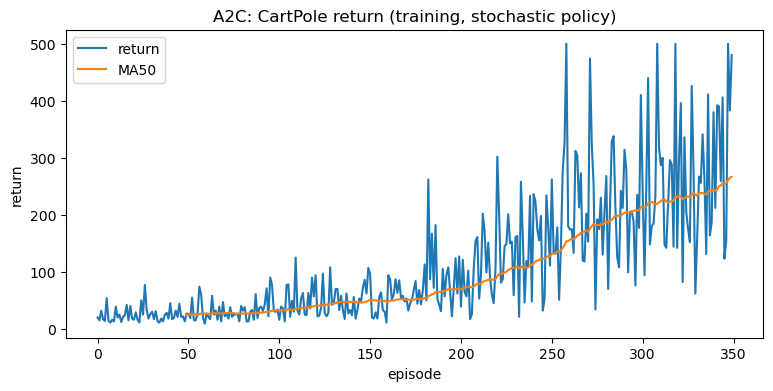

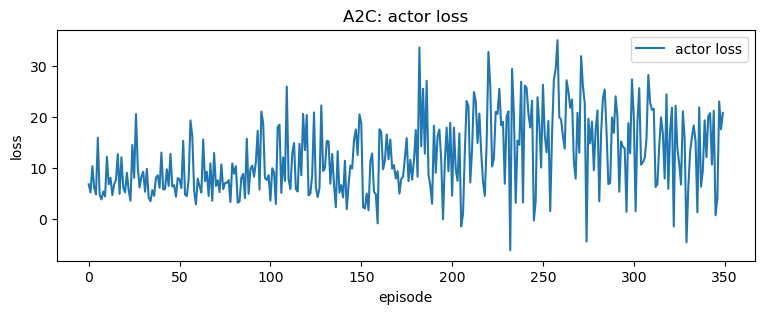

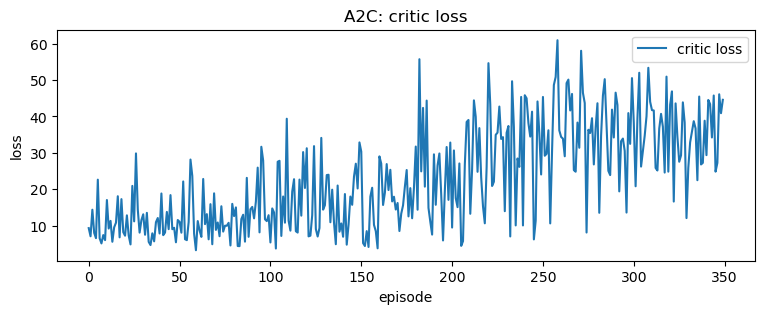

In [6]:
actor, critic, st = train_a2c(
    seed=0,
    episodes=350,
    gamma=0.99,
    lr=3e-4,
    entropy_coef=0.01,
    eval_every=50,
)

plt.figure(figsize=(9,4))
plt.plot(st["returns"], label="return")
plt.plot(np.arange(len(moving_average(st["returns"],50)))+49, moving_average(st["returns"],50), label="MA50")
plt.title("A2C: CartPole return (training, stochastic policy)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()

plt.figure(figsize=(9,3))
plt.plot(st["actor_loss"], label="actor loss")
plt.title("A2C: actor loss")
plt.xlabel("episode")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure(figsize=(9,3))
plt.plot(st["critic_loss"], label="critic loss")
plt.title("A2C: critic loss")
plt.xlabel("episode")
plt.ylabel("loss")
plt.legend()
plt.show()


# Ćwiczenia

## Definicje

In [7]:
# --- SAFETY: jeśli czegoś brakuje, zdefiniuj minimalnie (nie nadpisuje jeśli już jest) ---
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

if "ActorNet" not in globals():
    class ActorNet(nn.Module):
        def __init__(self, obs_dim, act_dim, hidden=128):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(obs_dim, hidden), nn.ReLU(),
                nn.Linear(hidden, hidden), nn.ReLU(),
                nn.Linear(hidden, act_dim)  # logits
            )
        def forward(self, x):
            return self.net(x)

if "CriticNet" not in globals():
    class CriticNet(nn.Module):
        def __init__(self, obs_dim, hidden=128):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(obs_dim, hidden), nn.ReLU(),
                nn.Linear(hidden, hidden), nn.ReLU(),
                nn.Linear(hidden, 1)
            )
        def forward(self, x):
            return self.net(x).squeeze(-1)

if "compute_returns" not in globals():
    def compute_returns(rewards, gamma=0.99):
        G = 0.0
        out = []
        for r in reversed(rewards):
            G = float(r) + gamma * G
            out.append(G)
        out.reverse()
        return np.array(out, dtype=np.float32)

if "a2c_act_sample" not in globals():
    @torch.no_grad()
    def a2c_act_sample(actor: ActorNet, obs):
        x = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        logits = actor(x).squeeze(0)
        dist = torch.distributions.Categorical(logits=logits)
        return int(dist.sample().item())

if "a2c_act_greedy" not in globals():
    @torch.no_grad()
    def a2c_act_greedy(actor: ActorNet, obs):
        x = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        logits = actor(x).squeeze(0)
        return int(torch.argmax(logits).item())


In [8]:
def train_a2c_runner(
    *,
    seed=0,
    episodes=250,
    gamma=0.99,
    lr=3e-4,
    hidden=128,
    value_coef=0.5,
    entropy_coef=0.01,
    grad_clip=10.0,
    eval_every=50,
    eval_episodes=20,
    # wstrzykiwane "klocki" do ćwiczeń:
    advantage_fn=None,      # advantage_fn(G_t, V) -> adv (torch tensor, (T,))
    actor_loss_fn=None,     # actor_loss_fn(logp, adv, entropy, entropy_coef) -> scalar loss
):
    assert advantage_fn is not None, "Podaj advantage_fn"
    assert actor_loss_fn is not None, "Podaj actor_loss_fn"

    seed_everything(seed)
    env = make_env("CartPole-v1", seed=seed, render=False)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    actor = ActorNet(obs_dim, act_dim, hidden=hidden).to(device)
    critic = CriticNet(obs_dim, hidden=hidden).to(device)
    opt = optim.Adam(list(actor.parameters()) + list(critic.parameters()), lr=lr)

    returns_hist = []
    actor_loss_hist = []
    critic_loss_hist = []
    eval_points = []

    for ep in range(1, episodes + 1):
        obs = reset_env(env, seed=seed + ep)
        states, actions, rewards = [], [], []
        done = False

        while not done:
            a = a2c_act_sample(actor, obs)
            obs2, r, done = step_env(env, a)
            states.append(obs)
            actions.append(a)
            rewards.append(r)
            obs = obs2

        G = compute_returns(rewards, gamma=gamma)  # (T,)
        s_t = torch.tensor(np.array(states), dtype=torch.float32, device=device)  # (T,obs)
        a_t = torch.tensor(np.array(actions), dtype=torch.int64, device=device)  # (T,)
        G_t = torch.tensor(G, dtype=torch.float32, device=device)                # (T,)

        logits = actor(s_t)                                    # (T,act_dim)
        dist = torch.distributions.Categorical(logits=logits)
        logp = dist.log_prob(a_t)                              # (T,)
        entropy = dist.entropy().mean()

        V = critic(s_t)                                        # (T,)

        adv = advantage_fn(G_t, V)                             # (T,)
        actor_loss = actor_loss_fn(logp, adv, entropy, entropy_coef)
        critic_loss = F.smooth_l1_loss(V, G_t)                 # Huber
        loss = actor_loss + value_coef * critic_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(list(actor.parameters()) + list(critic.parameters()), grad_clip)
        opt.step()

        ep_ret = float(np.sum(rewards))
        returns_hist.append(ep_ret)
        actor_loss_hist.append(float(actor_loss.item()))
        critic_loss_hist.append(float(critic_loss.item()))

        if ep % 20 == 0:
            ma50 = np.mean(returns_hist[-50:]) if len(returns_hist) >= 50 else np.mean(returns_hist)
            print(f"ep {ep:4d} | return={ep_ret:6.1f} | MA50={ma50:6.1f} | actorL={actor_loss_hist[-1]:.3f} | criticL={critic_loss_hist[-1]:.3f}")

        if eval_every and (ep % eval_every == 0):
            m, s = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor, ob), episodes=eval_episodes, seed=123)
            eval_points.append((ep, m))
            print(f"   [eval] ep {ep:4d} | greedy mean±std = {m:6.1f} ± {s:4.1f}")

    env.close()
    stats = {"returns": returns_hist, "actor_loss": actor_loss_hist, "critic_loss": critic_loss_hist, "eval_points": eval_points}
    return actor, critic, stats


# Ćwiczenie A2C-1 — Baseline vs brak baseline (REINFORCE-like)

## Ćwiczenie A2C-1 — Ablacja: baseline (critic) vs brak baseline

**Cel:** zobaczyć, że baseline $V(s)$ obniża wariancję gradientu.

W A2C advantage zwykle liczymy jako:

$
A_t = (G_t - V(s_t))
$

i **odcinamy gradient** (detach), żeby actor nie “pchał” critic.

Ablacja (REINFORCE-like):

$
A_t = G_t
$

czyli bez baseline — zwykle większa wariancja i gorsza stabilność.

**Zadanie:** uzupełnij funkcję `compute_advantage_a2c`.


In [9]:
def compute_advantage_a2c(G_t: torch.Tensor, V: torch.Tensor, use_baseline: bool = True) -> torch.Tensor:
    """
    Zwraca advantage (T,).

    G_t: returns (T,)
    V:   critic values (T,)

    Wersja z baseline:
      adv = (G_t - V).detach()

    Wersja bez baseline:
      adv = G_t.detach()

    TODO: uzupełnij kod.
    """
    if use_baseline:
        # TODO: policz advantage z baseline i zrób detach()
        raise NotImplementedError("TODO: baseline advantage")
    else:
        # TODO: policz advantage bez baseline i zrób detach()
        raise NotImplementedError("TODO: no-baseline advantage")


## Rozwiązanie:

In [10]:
def compute_advantage_a2c(G_t: torch.Tensor, V: torch.Tensor, use_baseline: bool = True) -> torch.Tensor:
    if use_baseline:
        return (G_t - V).detach()
    else:
        return G_t.detach()


ep   20 | return=  18.0 | MA50=  23.1 | actorL=6.150 | criticL=8.251
ep   40 | return=  18.0 | MA50=  24.2 | actorL=6.129 | criticL=7.882
   [eval] ep   55 | greedy mean±std =   38.9 ±  6.0
ep   60 | return=   9.0 | MA50=  26.8 | actorL=2.864 | criticL=3.285
ep   80 | return=  40.0 | MA50=  26.7 | actorL=10.880 | criticL=16.012
ep  100 | return=  34.0 | MA50=  32.6 | actorL=8.599 | criticL=12.906
   [eval] ep  110 | greedy mean±std =  150.9 ± 76.4
ep  120 | return=  57.0 | MA50=  39.4 | actorL=13.490 | criticL=20.372
ep  140 | return=  33.0 | MA50=  47.4 | actorL=6.655 | criticL=10.642
ep  160 | return=  11.0 | MA50=  47.0 | actorL=-0.854 | criticL=3.808
   [eval] ep  165 | greedy mean±std =  103.0 ± 27.6
ep  180 | return=  68.0 | MA50=  52.5 | actorL=11.547 | criticL=20.442
ep  200 | return= 127.0 | MA50=  70.3 | actorL=18.862 | criticL=32.843
ep  220 | return= 106.0 | MA50=  87.4 | actorL=14.705 | criticL=26.090
   [eval] ep  220 | greedy mean±std =  461.7 ± 59.4
ep   20 | return=  1

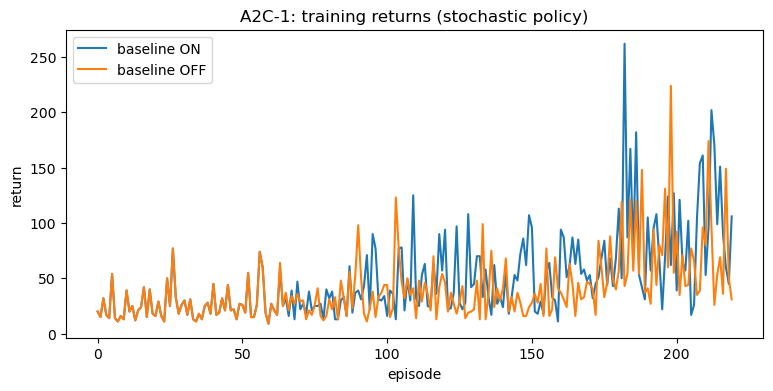

In [12]:
def actor_loss_basic(logp, adv, entropy, entropy_coef):
    # najprostsza wersja: -E[logπ * A] + entropy bonus
    return -(logp * adv).mean() - entropy_coef * entropy

# baseline ON
actor_b, critic_b, st_b = train_a2c_runner(
    seed=0, episodes=220,
    advantage_fn=lambda G,V: compute_advantage_a2c(G, V, use_baseline=True),
    actor_loss_fn=actor_loss_basic,
    entropy_coef=0.01,
    eval_every=55
)

# baseline OFF (REINFORCE-like)
actor_nb, critic_nb, st_nb = train_a2c_runner(
    seed=0, episodes=220,
    advantage_fn=lambda G,V: compute_advantage_a2c(G, V, use_baseline=False),
    actor_loss_fn=actor_loss_basic,
    entropy_coef=0.01,
    eval_every=55
)

m_b, s_b   = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor_b, ob), episodes=30, seed=123)
m_nb, s_nb = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor_nb, ob), episodes=30, seed=123)

print("=== EX A2C-1: greedy eval (30 ep) ===")
print(f"baseline ON : {m_b:.1f} ± {s_b:.1f}")
print(f"baseline OFF: {m_nb:.1f} ± {s_nb:.1f}")

plt.figure(figsize=(9,4))
plt.plot(st_b["returns"], label="baseline ON")
plt.plot(st_nb["returns"], label="baseline OFF")
plt.title("A2C-1: training returns (stochastic policy)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()


# Ćwiczenie A2C-2 — Entropy bonus (eksploracja)

## Ćwiczenie A2C-2 — Entropy bonus (eksploracja)

**Cel:** zrozumieć, po co w policy gradientach dodaje się składnik entropii.

Actor loss z entropią:

$
L_{\text{actor}} = -\mathbb{E}[\log\pi(a|s) A] - c_{ent}\, \mathbb{E}[H(\pi(\cdot|s))]
$

**Zadanie:** uzupełnij funkcję `actor_loss_with_entropy`.


In [13]:
def actor_loss_with_entropy(logp: torch.Tensor, adv: torch.Tensor, entropy: torch.Tensor, entropy_coef: float) -> torch.Tensor:
    """
    logp: (T,)
    adv:  (T,)
    entropy: scalar tensor (średnia entropia)
    entropy_coef: float

    TODO:
    - policz loss aktora: -(logp * adv).mean()
    - dodaj entropy bonus: - entropy_coef * entropy
    """
    # TODO: policy gradient term
    raise NotImplementedError("TODO: policy gradient term")

    # TODO: entropy term i return całości
    raise NotImplementedError("TODO: entropy bonus")


## Rozwiązanie

In [14]:
def actor_loss_with_entropy(logp: torch.Tensor, adv: torch.Tensor, entropy: torch.Tensor, entropy_coef: float) -> torch.Tensor:
    pg = -(logp * adv).mean()
    return pg - entropy_coef * entropy


ep   20 | return=  14.0 | MA50=  18.6 | actorL=5.016 | criticL=6.375
ep   40 | return=  14.0 | MA50=  19.7 | actorL=4.349 | criticL=6.048
   [eval] ep   55 | greedy mean±std =    9.3 ±  0.9
ep   60 | return=  25.0 | MA50=  20.8 | actorL=7.323 | criticL=10.429
ep   80 | return=  11.0 | MA50=  21.4 | actorL=1.993 | criticL=3.589
ep  100 | return=  14.0 | MA50=  22.9 | actorL=2.513 | criticL=4.406
   [eval] ep  110 | greedy mean±std =   12.7 ±  1.3
ep  120 | return=  15.0 | MA50=  20.1 | actorL=3.680 | criticL=4.518
ep  140 | return=  18.0 | MA50=  22.4 | actorL=2.849 | criticL=5.156
ep  160 | return=  19.0 | MA50=  23.4 | actorL=2.421 | criticL=4.647
   [eval] ep  165 | greedy mean±std =   24.4 ±  4.0
ep  180 | return=  15.0 | MA50=  26.7 | actorL=0.012 | criticL=3.410
ep  200 | return=  20.0 | MA50=  32.9 | actorL=1.034 | criticL=4.418
ep  220 | return=  35.0 | MA50=  39.9 | actorL=4.061 | criticL=8.449
   [eval] ep  220 | greedy mean±std =   66.1 ± 25.8
ep   20 | return=  14.0 | MA50= 

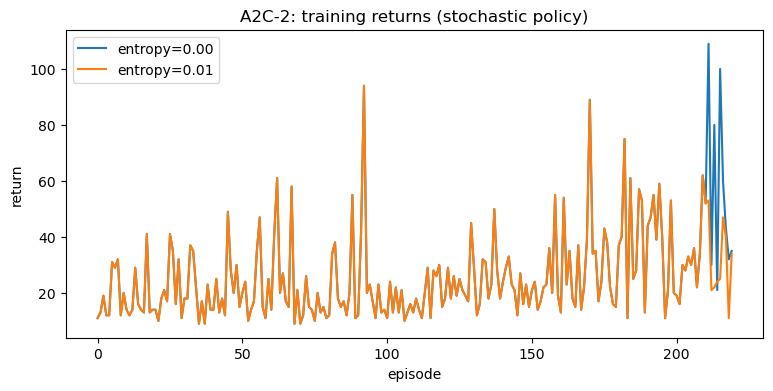

In [15]:
# Porównanie: entropy_coef = 0 vs 0.01 (reszta identyczna)

actor_e0, critic_e0, st_e0 = train_a2c_runner(
    seed=1, episodes=220,
    advantage_fn=lambda G,V: compute_advantage_a2c(G, V, use_baseline=True),
    actor_loss_fn=actor_loss_with_entropy,
    entropy_coef=0.0,
    eval_every=55
)

actor_e1, critic_e1, st_e1 = train_a2c_runner(
    seed=1, episodes=220,
    advantage_fn=lambda G,V: compute_advantage_a2c(G, V, use_baseline=True),
    actor_loss_fn=actor_loss_with_entropy,
    entropy_coef=0.01,
    eval_every=55
)

m0, s0 = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor_e0, ob), episodes=30, seed=123)
m1, s1 = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor_e1, ob), episodes=30, seed=123)

print("=== EX A2C-2: greedy eval (30 ep) ===")
print(f"entropy=0.00: {m0:.1f} ± {s0:.1f}")
print(f"entropy=0.01: {m1:.1f} ± {s1:.1f}")

plt.figure(figsize=(9,4))
plt.plot(st_e0["returns"], label="entropy=0.00")
plt.plot(st_e1["returns"], label="entropy=0.01")
plt.title("A2C-2: training returns (stochastic policy)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()


# Ćwiczenie A2C-3 — Normalizacja advantage (stabilność)

## Ćwiczenie A2C-3 — Normalizacja advantage

**Cel:** zobaczyć, że normalizacja advantage potrafi poprawić stabilność.

Normalizacja:

$
\hat{A} = \frac{A - \mu(A)}{\sigma(A)+\epsilon}
$

**Zadanie:** uzupełnij funkcję `normalize_advantages`.


## TODO:

In [16]:
def normalize_advantages(adv: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    adv: (T,)
    TODO:
    - policz mean i std
    - zwróć (adv - mean) / (std + eps)
    """
    # TODO
    raise NotImplementedError("TODO: normalize advantages")


## ROzwiązanie:


In [17]:
def normalize_advantages(adv: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return (adv - adv.mean()) / (adv.std() + eps)


ep   20 | return=  17.0 | MA50=  19.9 | actorL=5.168 | criticL=7.508
ep   40 | return=  27.0 | MA50=  20.7 | actorL=8.188 | criticL=11.373
   [eval] ep   55 | greedy mean±std =   12.6 ±  1.6
ep   60 | return=  12.0 | MA50=  21.4 | actorL=2.688 | criticL=4.129
ep   80 | return=  14.0 | MA50=  21.7 | actorL=3.851 | criticL=4.370
ep  100 | return=  27.0 | MA50=  26.9 | actorL=5.976 | criticL=9.357
   [eval] ep  110 | greedy mean±std =   91.5 ± 68.6
ep  120 | return=  12.0 | MA50=  29.6 | actorL=0.804 | criticL=2.855
ep  140 | return=  53.0 | MA50=  38.7 | actorL=10.312 | criticL=16.872
ep  160 | return=  20.0 | MA50=  42.0 | actorL=1.253 | criticL=4.760
   [eval] ep  165 | greedy mean±std =  233.8 ± 195.8
ep  180 | return=  57.0 | MA50=  48.4 | actorL=9.522 | criticL=15.358
ep  200 | return=  57.0 | MA50=  59.7 | actorL=6.966 | criticL=14.126
ep  220 | return= 104.0 | MA50=  72.6 | actorL=11.632 | criticL=24.499
   [eval] ep  220 | greedy mean±std =  299.3 ± 154.9
ep   20 | return=  23.0 

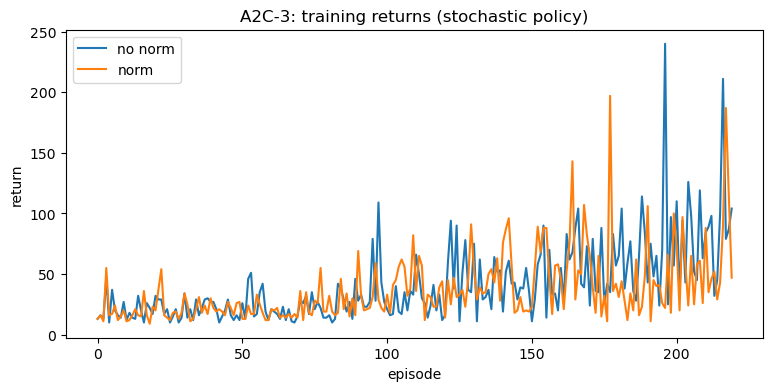

In [18]:
# porównanie: baseline advantage bez normalizacji vs z normalizacją
def adv_baseline_no_norm(G, V):
    return compute_advantage_a2c(G, V, use_baseline=True)

def adv_baseline_norm(G, V):
    adv = compute_advantage_a2c(G, V, use_baseline=True)
    return normalize_advantages(adv)

actor_n0, critic_n0, st_n0 = train_a2c_runner(
    seed=2, episodes=220,
    advantage_fn=adv_baseline_no_norm,
    actor_loss_fn=actor_loss_with_entropy,
    entropy_coef=0.01,
    eval_every=55
)

actor_n1, critic_n1, st_n1 = train_a2c_runner(
    seed=2, episodes=220,
    advantage_fn=adv_baseline_norm,
    actor_loss_fn=actor_loss_with_entropy,
    entropy_coef=0.01,
    eval_every=55
)

m0, s0 = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor_n0, ob), episodes=30, seed=123)
m1, s1 = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor_n1, ob), episodes=30, seed=123)

print("=== EX A2C-3: greedy eval (30 ep) ===")
print(f"no norm: {m0:.1f} ± {s0:.1f}")
print(f"norm   : {m1:.1f} ± {s1:.1f}")

plt.figure(figsize=(9,4))
plt.plot(st_n0["returns"], label="no norm")
plt.plot(st_n1["returns"], label="norm")
plt.title("A2C-3: training returns (stochastic policy)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import gymnasium as gym

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/piotr/anaconda3/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, act_dim)
        )
    def forward(self, x):
        return self.net(x)

class Critic(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

## Trening A2C

In [3]:
def train_a2c(episodes=400, gamma=0.99):
    env = gym.make('CartPole-v1')
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    actor = Actor(obs_dim, act_dim).to(device)
    critic = Critic(obs_dim).to(device)

    opt_actor = optim.Adam(actor.parameters(), lr=1e-3)
    opt_critic = optim.Adam(critic.parameters(), lr=1e-3)

    returns = []

    for ep in range(episodes):
        obs, _ = env.reset()
        done = False
        ep_return = 0

        while not done:
            obs_t = torch.tensor(obs, dtype=torch.float32).to(device)
            logits = actor(obs_t)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()

            next_obs, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated

            next_obs_t = torch.tensor(next_obs, dtype=torch.float32).to(device)

            value = critic(obs_t)
            next_value = critic(next_obs_t).detach()

            td_target = reward + gamma * next_value * (1 - int(done))
            advantage = td_target - value

            actor_loss = -dist.log_prob(action) * advantage.detach()
            critic_loss = advantage.pow(2)

            opt_actor.zero_grad(); actor_loss.backward(); opt_actor.step()
            opt_critic.zero_grad(); critic_loss.backward(); opt_critic.step()

            obs = next_obs
            ep_return += reward

        returns.append(ep_return)
        if (ep+1) % 50 == 0:
            print(f"Episode {ep+1}, avg return(last50)={np.mean(returns[-50:]):.1f}")

    env.close()
    return returns